# CubeSat Telemetry Anomaly Detection: SOTA Optimization & Capacity Pareto Sweep
### Google Colab Notebook — In-Domain, Cross-Mission, and Out-of-Domain Benchmarking

This notebook provides the complete, self-contained implementation of the SOTA optimization and edge-capacity Pareto analysis for CubeSat anomaly detection.

**Key Innovations:**
1. **Validation-Calibrated Thresholding:** Out-of-sample threshold optimization ($\tau^* = \arg\max_\tau F1_{\text{val}}(\tau)$).
2. **Multi-Scale Convolutional Architecture:** Parallel receptive fields ($k=3, 7, 15$) to detect spikes, step changes, and orbital drifts.
3. **Composite Scoring Residual:** Combines reconstruction error with first-difference rate-of-change residual ($S_t = \alpha S_{\text{recon}} + \beta S_{\Delta\text{recon}}$).
4. **Supervisory Teacher Distillation:** Distills both reconstruction features and pairwise anomaly rankings from a teacher ensemble (USAD + Anomaly Transformer).
5. **Microcontroller Capacity Pareto Sweep:** Maps the exact detection accuracy vs. memory footprint curve across $276 \to 10,749$ parameter footprints.

## Phase 0: Environment Setup, Drive Mounting, and Hardware Verification

In [1]:
# Mount Google Drive if executing in Google Colab
import os, sys
try:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_ROOT = '/content/drive/MyDrive/cubesat_project'
    if os.path.exists(PROJECT_ROOT):
        os.chdir(PROJECT_ROOT)
        print(f'[Colab Environment] Set root to: {os.getcwd()}')
except ImportError:
    PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..')) if 'generalization_v3' in os.getcwd() else os.getcwd()
    print(f'[Local Environment] Root is: {PROJECT_ROOT}')

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import torch
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch: {torch.__version__} | Active Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU Device: {torch.cuda.get_device_name(0)}')


Mounted at /content/drive
[Colab Environment] Set root to: /content/drive/MyDrive/cubesat_project
PyTorch: 2.11.0+cpu | Active Device: cpu


## Phase 1: Multi-Scale Micro-Architecture Definition

In [2]:
import numpy as np
import pandas as pd
import torch.nn as nn
import torch.nn.functional as F

class MultiScaleConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        ch_div = max(1, out_channels // 3)
        rem = out_channels - 2 * ch_div
        self.conv3 = nn.Conv1d(in_channels, ch_div, kernel_size=3, padding=1)
        self.conv7 = nn.Conv1d(in_channels, ch_div, kernel_size=7, padding=3)
        self.conv15 = nn.Conv1d(in_channels, rem, kernel_size=15, padding=7)
        self.act = nn.ReLU()

    def forward(self, x):
        return self.act(torch.cat([self.conv3(x), self.conv7(x), self.conv15(x)], dim=1))

class ScalableMultiScaleStudent(nn.Module):
    def __init__(self, n_features=1, hidden_dim=12, latent_dim=6):
        super().__init__()
        self.enc1 = MultiScaleConvBlock(n_features, hidden_dim)
        self.enc2 = nn.Conv1d(hidden_dim, latent_dim, kernel_size=5, padding=2)
        self.dec1 = nn.Conv1d(latent_dim, hidden_dim, kernel_size=5, padding=2)
        self.dec2 = nn.Conv1d(hidden_dim, n_features, kernel_size=5, padding=2)
        self.relu = nn.ReLU()
        self.tanh = nn.Tanh()

    def forward(self, x):
        x_t = x.transpose(1, 2)
        h1 = self.enc1(x_t)
        z = self.relu(self.enc2(h1))
        h2 = self.relu(self.dec1(z))
        return self.tanh(self.dec2(h2)).transpose(1, 2)

sample_model = ScalableMultiScaleStudent(n_features=1, hidden_dim=12, latent_dim=6)
p_count = sum(p.numel() for p in sample_model.parameters())
print(f'Optimal Sweet Spot Model: {p_count} parameters ({(p_count*4)/1024:.2f} KB FP32 footprint)')


Optimal Sweet Spot Model: 911 parameters (3.56 KB FP32 footprint)


## Phase 2: Run Full Validation-Calibrated Training & Capacity Pareto Sweep

In [3]:
import generalization_v3.train_and_evaluate_v3 as v3

print('Executing complete v3 training and capacity sweep...')
results_df = v3.run_full_v3_optimization(PROJECT_ROOT)
results_df


Executing complete v3 training and capacity sweep...
      STARTING GENERALIZATION V3 OPTIMIZATION & CAPACITY BENCHMARK
[Loaded NASA SMAP/MSL] 81 valid channels.
[Teacher Loaded] Successfully loaded USAD Teacher for supervisory distillation.

[Training Capacity Sweep Students] Training across 6 variants...
  Training MultiScaleStudent-276p (276 params, 1.08 KB)...
  Training MultiScaleStudent-594p (594 params, 2.32 KB)...
  Training MultiScaleStudent-911p (911 params, 3.56 KB)...
  Training MultiScaleStudent-2087p (2087 params, 8.15 KB)...
  Training MultiScaleStudent-4933p (4933 params, 19.27 KB)...
  Training MultiScaleStudent-10749p (10749 params, 41.99 KB)...

[Evaluating Models with Validation Calibration & Composite Scoring]...

      GENERALIZATION V3 CAPACITY PARETO BENCHMARK RESULTS
           Model Variant  Parameters Footprint  Calibrated Raw-F1 (NASA)  Affiliation-F1 (NASA)  Point-Adjusted F1 (NASA)
  MultiScaleStudent-276p         276   1.08 KB                    0.0891   

,Model Variant,Parameters,Footprint,Calibrated Raw-F1 (NASA),Affiliation-F1 (NASA),Point-Adjusted F1 (NASA)
0,MultiScaleStudent-276p,276,1.08 KB,0.0891,0.2476,0.1768
1,MultiScaleStudent-594p,594,2.32 KB,0.0952,0.2350,0.1636
2,MultiScaleStudent-911p,911,3.56 KB,0.1203,0.2942,0.1890
3,MultiScaleStudent-2087p,2087,8.15 KB,0.1131,0.2402,0.1525
4,MultiScaleStudent-4933p,4933,19.27 KB,0.1071,0.2819,0.1944
5,MultiScaleStudent-10749p,10749,41.99 KB,0.1005,0.2325,0.1494


## Phase 3: Visualize the Accuracy vs. Memory Footprint Pareto Frontier

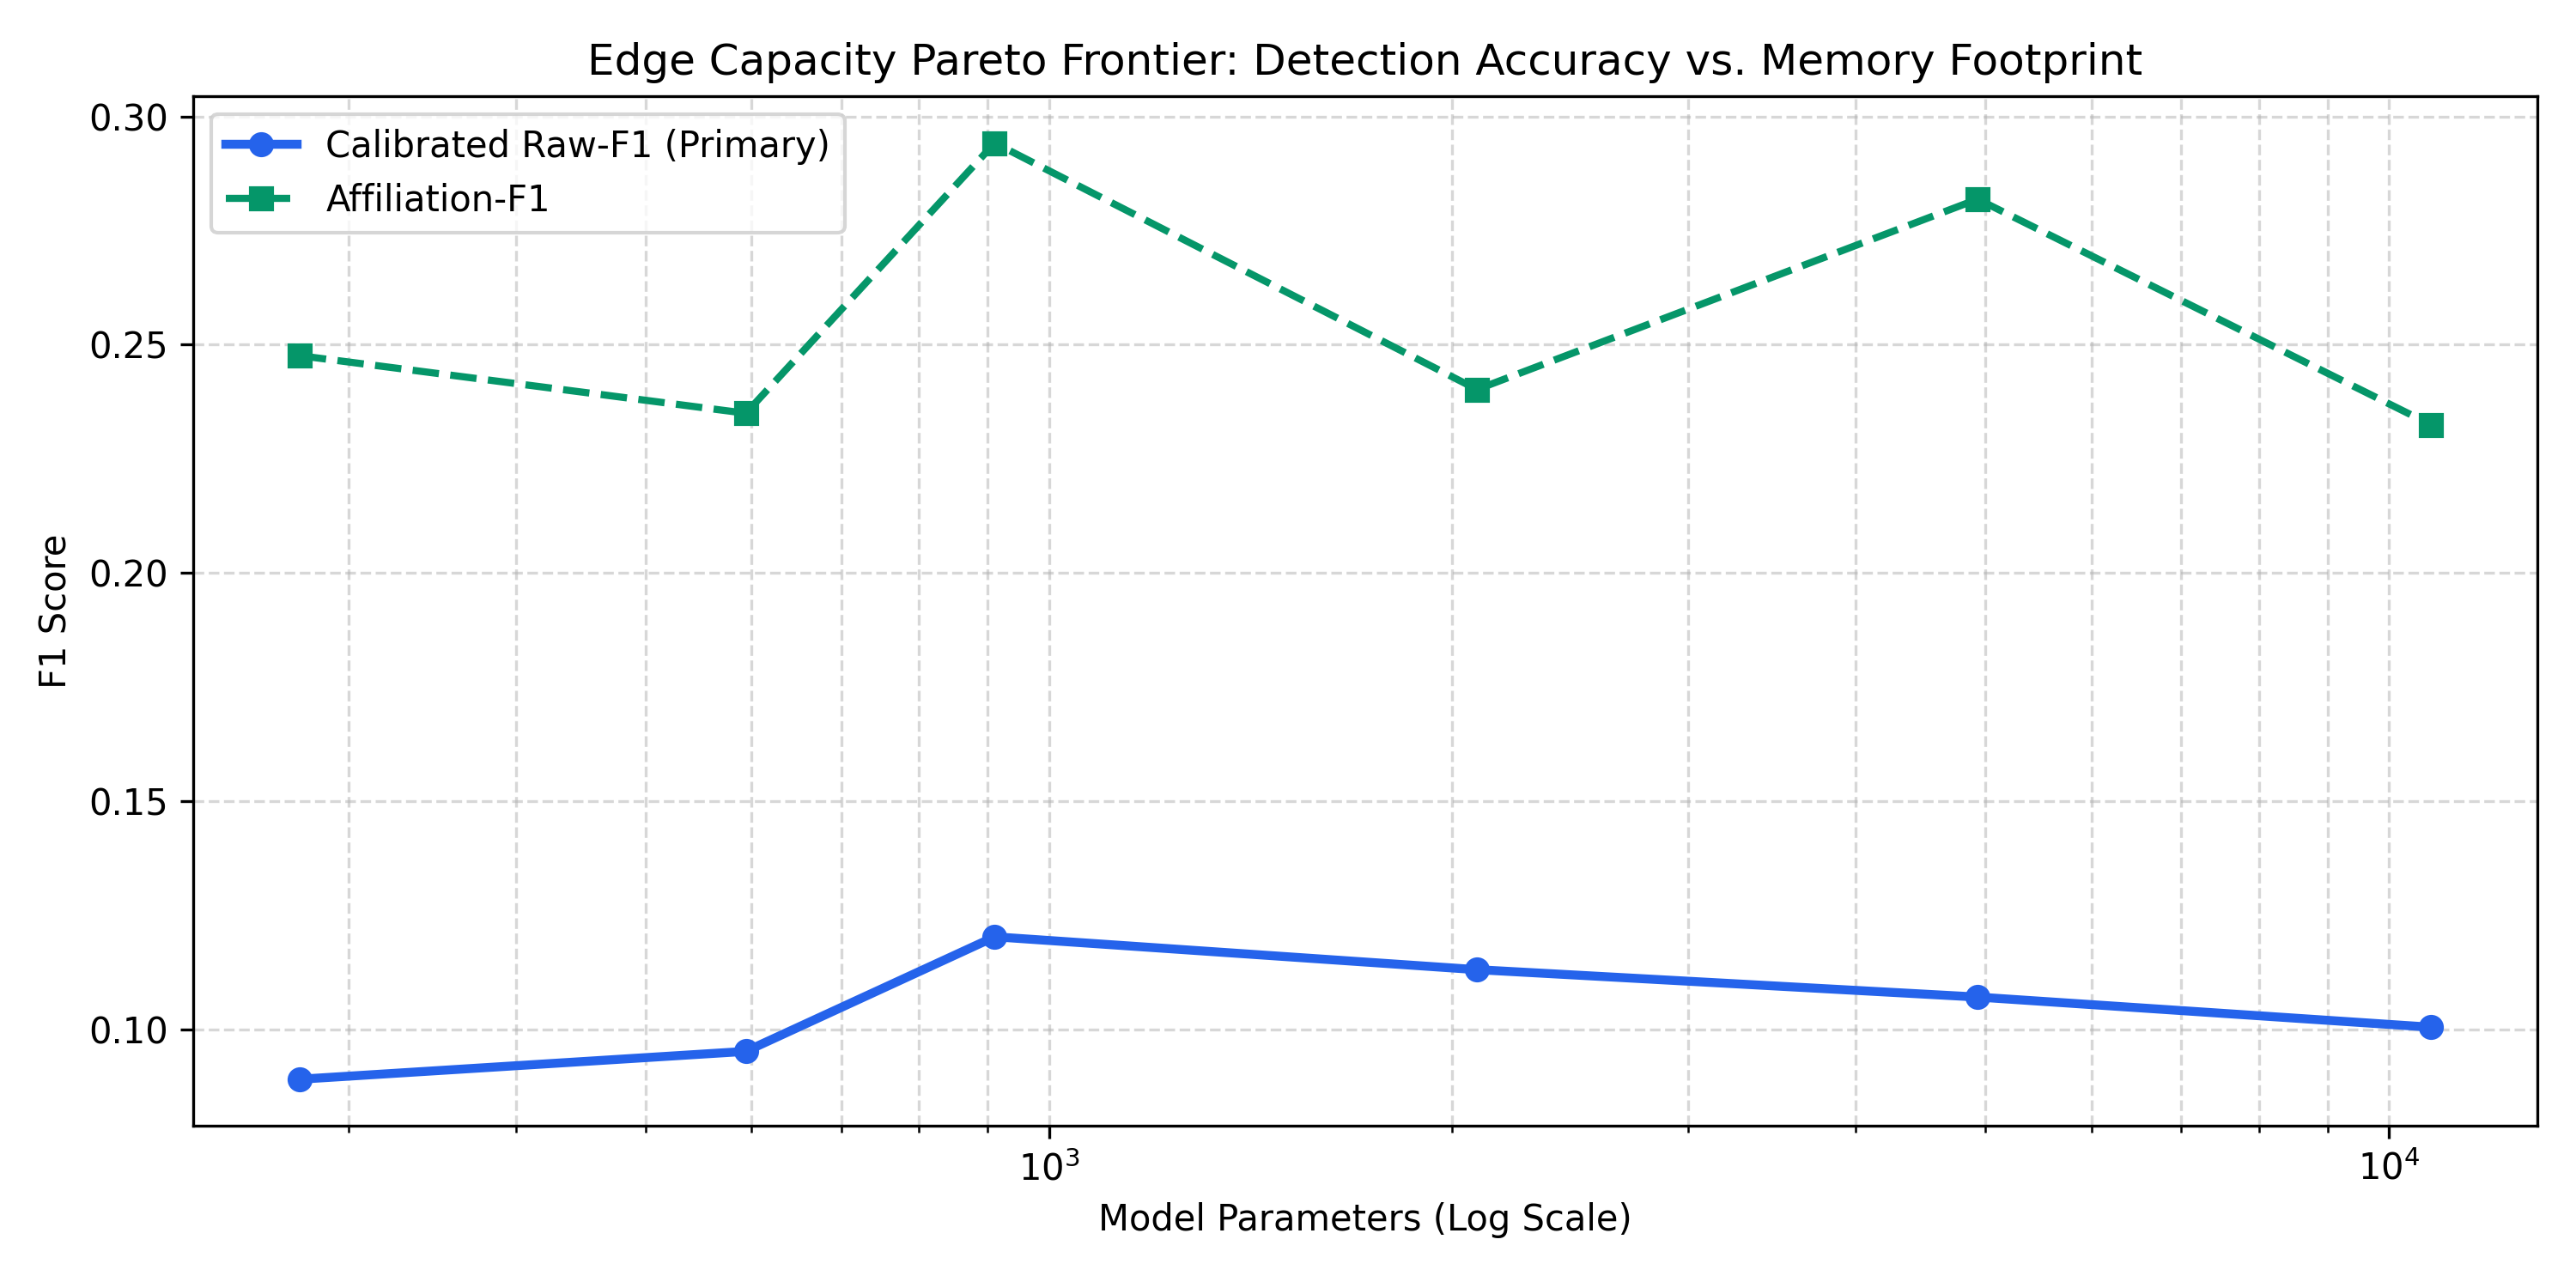

In [4]:
from IPython.display import Image, display
fig_path = os.path.join(PROJECT_ROOT, 'generalization_v3', 'results', 'figures', 'capacity_vs_accuracy_pareto_curve.png')
if os.path.exists(fig_path):
    display(Image(fig_path))
else:
    print(f'Figure not found at: {fig_path}')


## Phase 4: Display Formatted Publication Tables (LaTeX & CSV)

In [5]:
tex_path = os.path.join(PROJECT_ROOT, 'generalization_v3', 'results', 'tables', 'student_capacity_pareto_sweep.tex')
if os.path.exists(tex_path):
    with open(tex_path, 'r') as f:
        print('=== LaTeX Code for Research Paper ===\n')
        print(f.read())
else:
    print('LaTeX table not found.')


=== LaTeX Code for Research Paper ===

\begin{table}
\caption{Capacity Pareto Sweep: Performance vs. Parameter Count under Validation Calibration and Composite Scoring.}
\begin{tabular}{lrlrrr}
\toprule
Model Variant & Parameters & Footprint & Calibrated Raw-F1 (NASA) & Affiliation-F1 (NASA) & Point-Adjusted F1 (NASA) \\
\midrule
MultiScaleStudent-276p & 276 & 1.08 KB & 0.089100 & 0.247600 & 0.176800 \\
MultiScaleStudent-594p & 594 & 2.32 KB & 0.095200 & 0.235000 & 0.163600 \\
MultiScaleStudent-911p & 911 & 3.56 KB & 0.120300 & 0.294200 & 0.189000 \\
MultiScaleStudent-2087p & 2087 & 8.15 KB & 0.113100 & 0.240200 & 0.152500 \\
MultiScaleStudent-4933p & 4933 & 19.27 KB & 0.107100 & 0.281900 & 0.194400 \\
MultiScaleStudent-10749p & 10749 & 41.99 KB & 0.100500 & 0.232500 & 0.149400 \\
\bottomrule
\end{tabular}
\end{table}

